# Bandstructure with Py4VASP


In [1]:
# Prework

import matplotlib.pyplot as plt
import numpy as np

from py4vasp import Calculation
from vmatplot.output_settings import color_sampling, canvas_setting


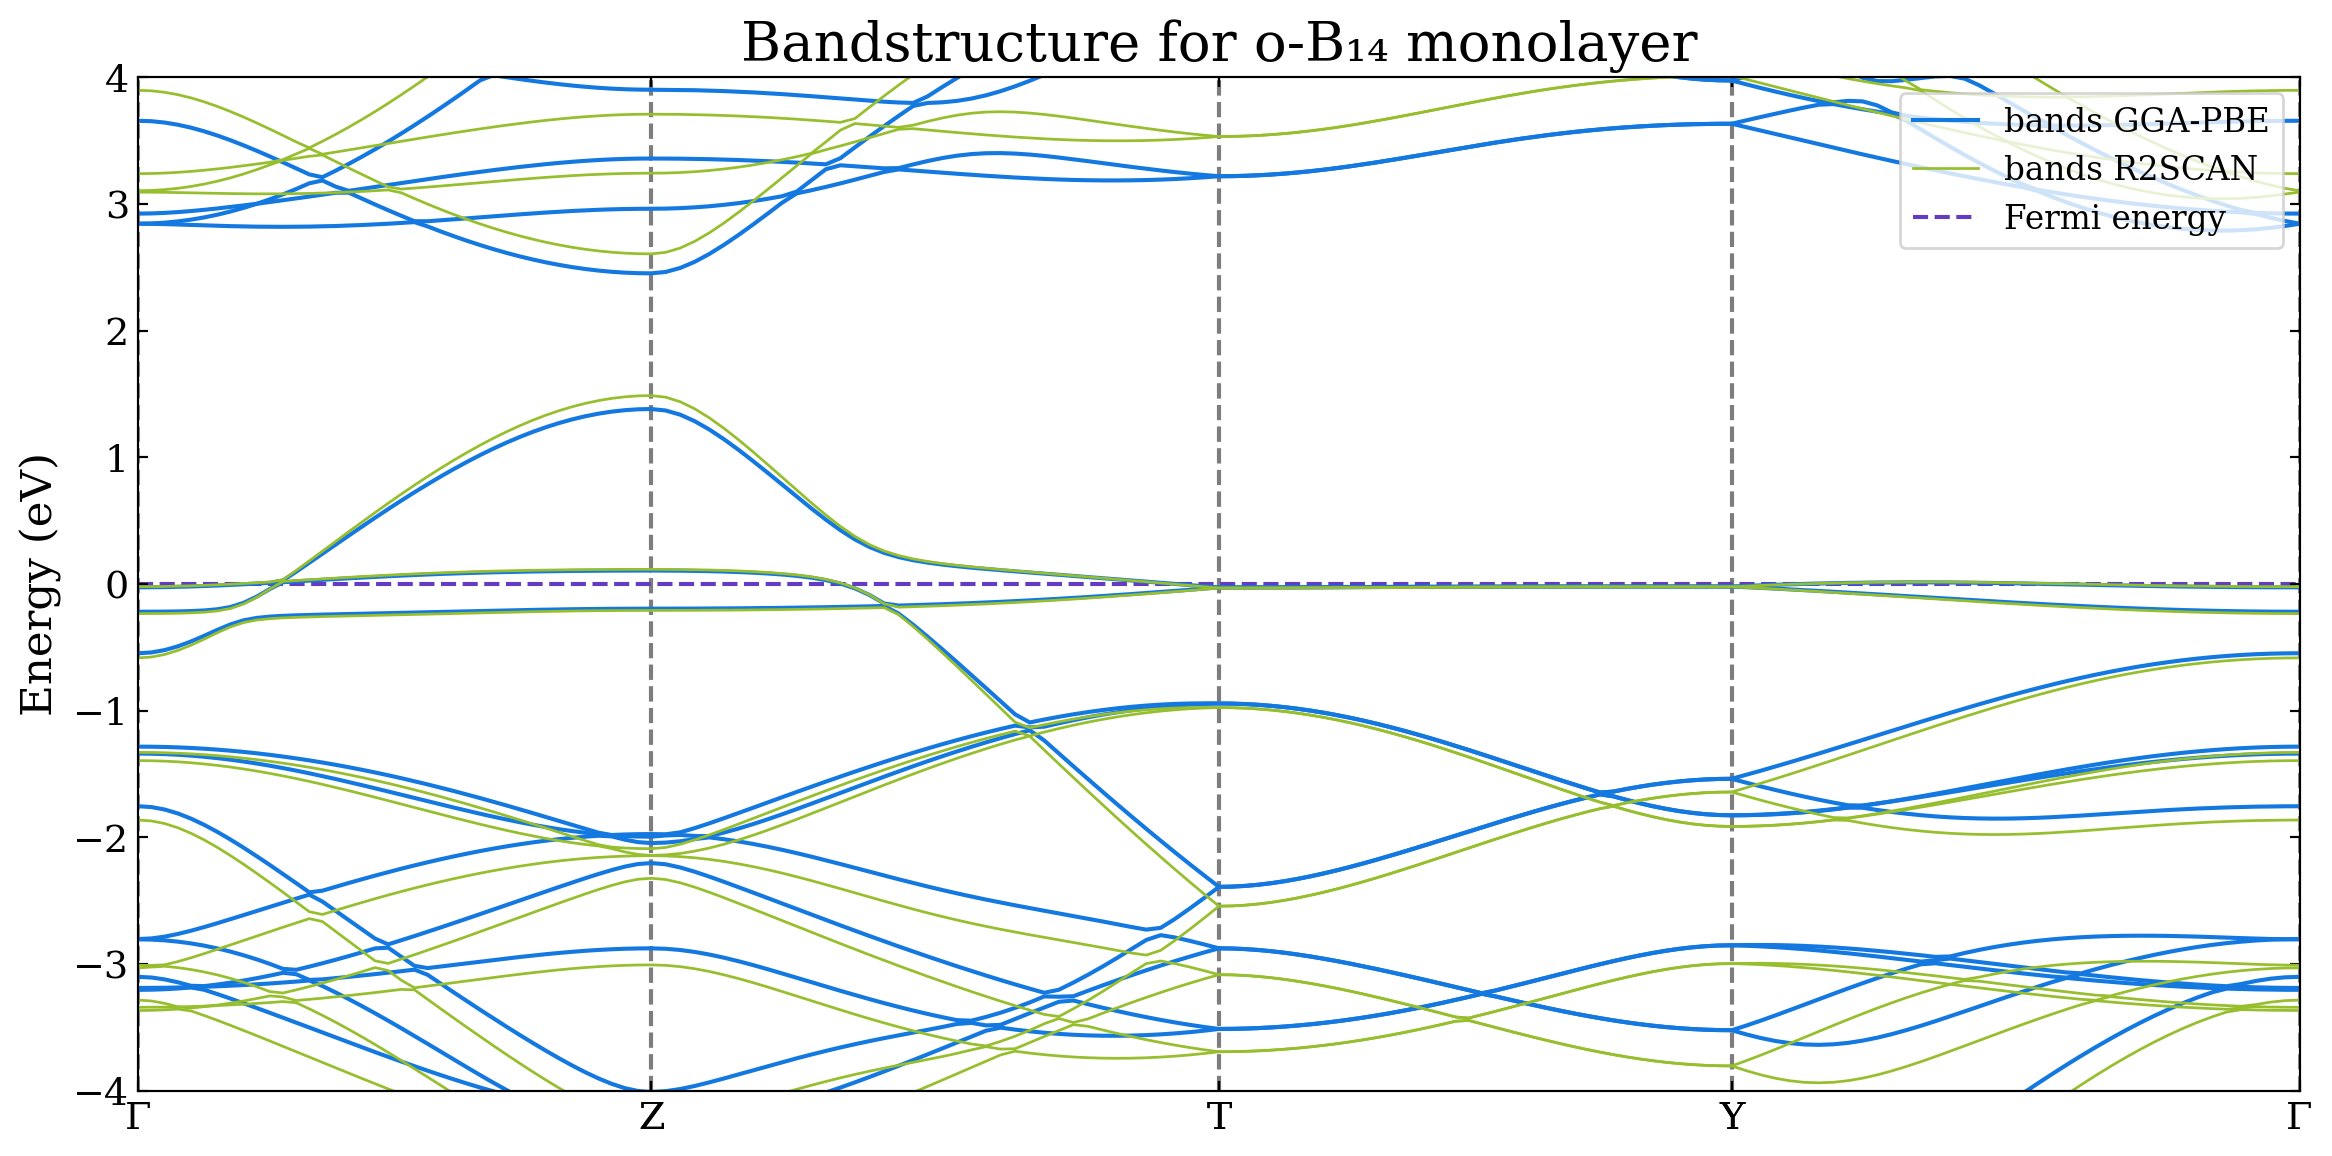

In [2]:
#### o-B₁₄ monolayer

# extract data

dir_PBE = "3.1_bandstructure/monolayer"
# dir_HSE = "3.1_bandstructure/monolayer_HSE"  # Uncomment if needed
dir_R2SCAN = "3.1_bandstructure/monolayer_R2SCAN"

calc_PBE = Calculation.from_path(dir_PBE)
calc_R2SCAN = Calculation.from_path(dir_R2SCAN)

data_PBE = calc_PBE.band.to_dict()
data_R2SCAN = calc_R2SCAN.band.to_dict(selection="KPOINTS_OPT")

bands_PBE = np.array(data_PBE.get("bands"))
bands_R2SCAN = np.array(data_R2SCAN.get("bands"))

kpoints_PBE = np.array(data_PBE.get("kpoint_distances"))
kpoints_R2SCAN = np.array(data_R2SCAN.get("kpoint_distances"))

kpoints_labels_PBE = data_PBE.get("kpoint_labels")
kpoints_labels_R2SCAN = data_R2SCAN.get("kpoint_labels")

# Indices of high-symmetry

indices = np.where(np.array(kpoints_labels_PBE) != "")[0]
ticks = kpoints_PBE[indices]
ticklabels = [kpoints_labels_PBE[index] for index in indices]

# Plot figure

fig_setting = canvas_setting(12, 6)
params = fig_setting[2]; plt.rcParams.update(params)

fig, ax = plt.subplots(figsize=fig_setting[0], dpi=fig_setting[1])
plt.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)

for band in bands_PBE.T:
    ax.plot(kpoints_PBE, band, color=color_sampling("blue")[1], lw=1.5, label="bands GGA-PBE" if np.all(band == bands_PBE.T[0]) else "")
for band in bands_R2SCAN.T:
    ax.plot(kpoints_PBE, band, color=color_sampling("Lime")[1], lw=1, label="bands R2SCAN" if np.all(band == bands_R2SCAN.T[0]) else "")

# Set high-symmetry k-points as x-axis ticks
ax.set_xticks(ticks)
ax.set_xticklabels(ticklabels)

# Draw a horizontal line at the Fermi level and vertical lines at high-symmetry points
ax.axhline(0, color=color_sampling("Violet")[0], lw=1.5, linestyle="--", label="Fermi energy", zorder=-1)
for xc in ticks:
    ax.axvline(x=xc, color=color_sampling("Grey")[1], lw=1.5, alpha=0.8, linestyle="--", zorder=-2)

# Set axis labels and title
# ax.set_xlabel("K-path")
ax.set_ylabel("Energy (eV)")
ax.set_xlim(kpoints_PBE[0], kpoints_PBE[-1])
ax.set_ylim(-4,4)
ax.set_title("Bandstructure for o-B₁₄ monolayer")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()
